In [1]:
!pip install pandas==2.3.3
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
dopamine-rl 4

# DATA PREP

In [2]:
# ============================================================
# DATA PREP — PHYSIONET 2017 (DROP-IN REPLACEMENT)
# ============================================================

import os
import numpy as np
import pandas as pd
import wfdb
from collections import Counter
from scipy.signal import resample

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

FS = 300
TARGET_FS = 300
SEG_LEN = 9000

ROOT_DIR = "/kaggle/input/physionet-af-dataset-modified/PhysioNet_AF_Dataset_modified/physionet.org/files/challenge-2017/1.0.0"
TRAIN_DIR = os.path.join(ROOT_DIR, "training")
VAL_DIR   = os.path.join(ROOT_DIR, "validation")
TRAIN_REF = os.path.join(TRAIN_DIR, "REFERENCE.csv")
VAL_REF   = os.path.join(VAL_DIR, "REFERENCE.csv")

def read_physionet_2017_records(base_dir, ref_csv):
    ref = pd.read_csv(ref_csv, header=None, names=["record", "label"])
    label_map = {"N": "N", "A": "A", "O": None, "~": None}

    Signals, Labels, Ids = [], [], []
    for _, row in ref.iterrows():
        rec = row["record"]
        lbl = label_map.get(row["label"])
        if lbl is None:
            continue
        try:
            record = wfdb.rdrecord(os.path.join(base_dir, rec))
            sig = record.p_signal[:, 0].astype(np.float32)
            sig = resample(sig, int(len(sig) * TARGET_FS / FS))
            if len(sig) >= SEG_LEN:
                Signals.append(sig)
                Labels.append(lbl)
                Ids.append(rec)
        except:
            continue
    return Signals, pd.Series(Labels, dtype="category"), np.array(Ids)

Signals_tr, Labels_tr, Ids_tr = read_physionet_2017_records(TRAIN_DIR, TRAIN_REF)
Signals_va, Labels_va, Ids_va = read_physionet_2017_records(VAL_DIR, VAL_REF)

Signals = Signals_tr + Signals_va
Labels  = pd.concat([Labels_tr, Labels_va], ignore_index=True)
Ids     = np.concatenate([Ids_tr, Ids_va])

records_df = pd.DataFrame({"id": Ids, "signal": Signals, "label": Labels})
print("Label distribution:", Counter(Labels))

train_ids, test_ids = train_test_split(
    records_df["id"].unique(), test_size=0.2, random_state=42
)

train_df = records_df[records_df["id"].isin(train_ids)].reset_index(drop=True)
test_df  = records_df[records_df["id"].isin(test_ids)].reset_index(drop=True)

def segment_signals_from_df(df, seg_len=SEG_LEN):
    X, Y = [], []
    for _, row in df.iterrows():
        x, y = row["signal"], row["label"]
        for i in range(len(x) // seg_len):
            X.append(x[i*seg_len:(i+1)*seg_len])
            Y.append(y)
    return X, Y

XTest, YTest = segment_signals_from_df(test_df)
le_test = LabelEncoder()
YTest_enc = le_test.fit_transform(YTest)

2026-02-02 11:00:54.988472: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770030055.185232      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770030055.238543      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770030055.698736      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770030055.698787      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770030055.698789      24 computation_placer.cc:177] computation placer alr

Label distribution: Counter({'N': 4686, 'A': 688})


# LATE FUSION + G-MEAN

Fusion input shape: (1190, 3)


I0000 00:00:1770030156.479412      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770030156.485244      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

I0000 00:00:1770030158.853042      82 service.cc:152] XLA service 0x7808ac00bed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770030158.853075      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770030158.853079      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770030159.165826      82 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770030160.682116      82 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



================ LATE FUSION RESULTS (thr = 0.5) ================

Accuracy     : 0.9706
Precision    : 0.9891
Recall (Sens): 0.9764
Specificity  : 0.9360
F1-score     : 0.9827
G-Mean       : 0.9560
AUC          : 0.9826


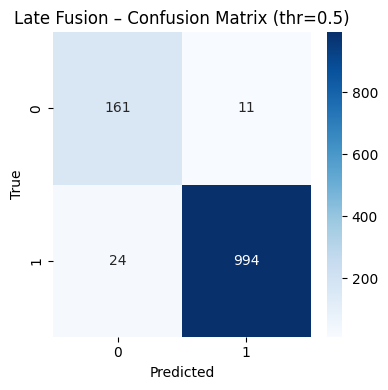

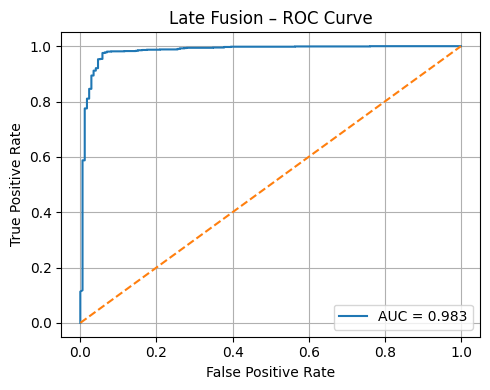


================ BEST G-MEAN (THRESHOLD TUNING) ================

Best Threshold : 0.51
Sensitivity    : 0.9754
Specificity    : 0.9419
G-Mean         : 0.9585


In [3]:
# ============================================================
# LATE FUSION + FINAL METRICS + G-MEAN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score
)
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# LOAD SAVED PROBABILITIES
# ------------------------------------------------------------
y_prob_raw  = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/raw/y_prob_raw.npy")
y_prob_stft = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/stft/y_prob_stft.npy")
y_prob_cwt  = np.load("/kaggle/input/individualmodeloutputs-for-fusionmodel/run2_outputs/cwt/y_prob_cwt.npy")

X_fusion = np.column_stack([y_prob_raw, y_prob_stft, y_prob_cwt]).astype(np.float32)
y_true = YTest_enc.astype(np.int32)

print("Fusion input shape:", X_fusion.shape)

# ------------------------------------------------------------
# FUSION HEAD (UNCHANGED)
# ------------------------------------------------------------
tf.keras.backend.clear_session()

inp = Input(shape=(3,))
x = Dense(16, activation="relu")(inp)
x = Dropout(0.3)(x)
x = Dense(8, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(1, activation="sigmoid")(x)

fusion_model = Model(inp, out)
fusion_model.compile(
    optimizer=Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fusion_model.summary()

# ------------------------------------------------------------
# TRAIN FUSION MODEL
# ------------------------------------------------------------
fusion_model.fit(
    X_fusion,
    y_true,
    epochs=50,
    batch_size=128,
    verbose=0
)

fusion_model.save("late_fusion_model.h5")

# ------------------------------------------------------------
# PREDICTIONS (DEFAULT THRESHOLD = 0.5)
# ------------------------------------------------------------
y_prob_fused = fusion_model.predict(X_fusion, verbose=0).ravel()
y_pred_fused = (y_prob_fused >= 0.5).astype(int)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_fused).ravel()

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------
acc  = accuracy_score(y_true, y_pred_fused)
prec = precision_score(y_true, y_pred_fused)
rec  = recall_score(y_true, y_pred_fused)          # Sensitivity
spec = tn / (tn + fp + 1e-8)                        # Specificity
f1   = f1_score(y_true, y_pred_fused)

gmean_05 = np.sqrt(rec * spec)

auc = roc_auc_score(y_true, y_prob_fused)

print("\n================ LATE FUSION RESULTS (thr = 0.5) ================\n")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall (Sens): {rec:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"G-Mean       : {gmean_05:.4f}")
print(f"AUC          : {auc:.4f}")

# ------------------------------------------------------------
# CONFUSION MATRIX PLOT
# ------------------------------------------------------------
plt.figure(figsize=(4,4))
sns.heatmap(
    confusion_matrix(y_true, y_pred_fused),
    annot=True, fmt="d", cmap="Blues"
)
plt.title("Late Fusion – Confusion Matrix (thr=0.5)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_prob_fused)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Late Fusion – ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# THRESHOLD TUNING FOR MAX G-MEAN
# ------------------------------------------------------------
thresholds = np.linspace(0.05, 0.95, 91)
best_gmean, best_thr = 0.0, 0.5
best_stats = None

for t in thresholds:
    y_pred = (y_prob_fused >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)
    gmean = np.sqrt(sens * spec)

    if gmean > best_gmean:
        best_gmean = gmean
        best_thr = t
        best_stats = (sens, spec)

print("\n================ BEST G-MEAN (THRESHOLD TUNING) ================\n")
print(f"Best Threshold : {best_thr:.2f}")
print(f"Sensitivity    : {best_stats[0]:.4f}")
print(f"Specificity    : {best_stats[1]:.4f}")
print(f"G-Mean         : {best_gmean:.4f}")